# SI 313 WN26: Surveys Module Assignment
### Part B: Survey Data Analysis
##### Nick Pisarczyk - 03/25/26
---

## Introduction
- Research question and motivation
- Specific hypotheses you're testing

Choose ONE research question to investigate:

- Trust in institutions: What predicts trust in government institutions (Congress, presidency, media, science)? How do political affiliation, education, and demographic factors relate to institutional trust?
- Information sources and beliefs: How do different news sources (traditional media, social media, partisan outlets) relate to political knowledge, beliefs about factual matters, or policy preferences?
- Identity and political attitudes: How do different social identities (race, gender, education, religion, region) relate to political preferences? Are there interaction effects between identities?

### <b>I chose: - Information sources and beliefs: How do different news sources (traditional media, social media, partisan outlets) relate to political knowledge, beliefs about factual matters, or policy preferences?</b> And I focused on the "political knowledge" aspect of the question ##

---

## Data Loading and Exploration
- Load ANES data
- Examine variables of interest
- Check missing data patterns
- Create necessary derived variables

In [16]:
# libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import chi2_contingency

In [17]:
# Load the 2020 ANES Time Series data
# df = pd.read_csv("/Users/libbyh/Documents/git/si313_instructors/answer_keys/data/38034-0001-Data.tsv", sep='\t')
df = pd.read_stata("../data/surveys_module_data/38034-0001-Data.dta", convert_categoricals=False)

# news/media sources
# rename variables with friendly names
df = df.rename(columns={
    "V201629A": "tv_used",                   # data about what media sources people heard anything about the presidential campaign from 
    "V201629B": "newspaper_used",            # covers traditional source use of radio/newspaper
    "V201629C": "internet_used",
    "V201629D": "radio_used",

    "V200010B": "weight_full_post",          # full-sample post-election weight
})

# political knowledge
# rename variables with friendly names
df = df.rename(columns={
    "V201644": "senator_term",
    "V201645": "least_fed_spending",
    "V201646": "house_majority",
    "V201647": "senate_majority",
})

facts = ["senator_term", "least_fed_spending", "house_majority", "senate_majority"]
media = ["tv_used", "newspaper_used", "internet_used", "radio_used"]
weights = ["weight_full_post"]

combined_vars = facts+media
vars_and_weights = combined_vars+weights

model_df = df[vars_and_weights].copy()

print(f"head of new dataset")
print(model_df.head())

head of new dataset
   senator_term  least_fed_spending  house_majority  senate_majority  tv_used  \
0             6                   3               1                2        1   
1             2                   4               2                1        1   
2             6                   1               1                2        1   
3             4                   1               2                1        1   
4             6                   1               1                2        1   

   newspaper_used  internet_used  radio_used  weight_full_post  
0               0              1           1          0.611133  
1               0              1           0          1.209783  
2               1              1           1          0.823936  
3               0              0           0          0.512837  
4               0              1           1          0.856575  


In [18]:
"""
 Recode factual knowledge questions to get binary right or wrong values
    - correct answers are 1
    - incorrect answers are 0
    - all others are NaN
"""

model_df_recoded = model_df.copy()
fact_cols = {'senator_term':6, 'least_fed_spending':1, 'house_majority':1, 'senate_majority':2}
media_cols = media.copy()

# helper functions for recodinng factual questions
def recode_factual_questions(column_name, correct_val):
    conditions = [
            df[column_name] == correct_val,
            df[column_name] > 0,
            df[column_name] < 0,
        ]
    choices = [
        1,
        0,
        np.nan,
    ]

    model_df_recoded[f"{column_name}"] = np.select(conditions, choices, default=model_df_recoded[column_name])
    # print(f"model_df column: {model_df[column_name]}")
    print(f"{column_name} unique vals: {model_df_recoded[column_name].unique()}")

def compare_column_values_factual(column_name, correct_val):
    print(f"ORIGINAL VARS: Column {column_name}:\nCorrect Value = {correct_val}\n{model_df[column_name].value_counts(dropna=False)}\n")
    print(f"RECODED VARS: Column {column_name}:\nCorrect Value = 1.0\n{model_df_recoded[column_name].value_counts(dropna=False)}\n{'='*50}\n\n\n\n")

def compare_frequencies_factual(column_name, correct_val):
    # need the correct answer, any NaNs, any incorrect
    # for first, need 6, any > 0 and not 6, any negative
    n_correct_before = (model_df[column_name] == correct_val).sum()
    n_incorrect_before = ((model_df[column_name] > 0) & ((model_df)[column_name] != correct_val)).sum()
    n_negative_before = (model_df[column_name] < 0).sum()

    # compare now to recoded
    n_correct_after = (model_df_recoded[column_name] == 1.0).sum()
    n_incorrect_after = (model_df_recoded[column_name] == 0.0).sum()
    n_negative_after = model_df_recoded[column_name].isna().sum()

    print(f"For column {column_name}:\nCorrect answers before | after recoding:   {n_correct_before} | {n_correct_after}\nIncorrect answers before | after recoding: {n_incorrect_before} | {n_incorrect_after}\nNegative answers before | after recoding:  {n_negative_before}  |  {n_negative_after}\n")

    if not n_correct_before == n_correct_after and not n_incorrect_before == n_incorrect_after and not n_negative_before == n_negative_after:
        print(f"Error! {column_name} recoded incorrectly.")


# helper functions for recoding all other columns
def recode_media(column_name):
    conditions = [
            df[column_name] > 0,
            df[column_name] == 0,
            df[column_name] < 0,
        ]
    choices = [
        1,
        0,
        np.nan,
    ]

    model_df_recoded[f"{column_name}"] = np.select(conditions, choices, default=model_df_recoded[column_name])
    print(f"{column_name} unique vals: {model_df_recoded[column_name].unique()}")

def compare_column_values_media(column_name):
    print(f"ORIGINAL VARS: Column {column_name}:\n{model_df[column_name].value_counts(dropna=False)}\n")
    print(f"RECODED VARS: Column {column_name}:\n{model_df_recoded[column_name].value_counts(dropna=False)}\n{'='*50}\n\n\n\n")

def compare_frequencies_media(column_name):
    # need the yes', any NaNs, any nos
    n_yes_before = (model_df[column_name] == 1).sum()
    n_no_before = (model_df[column_name] == 0).sum()
    n_negative_before = (model_df[column_name] < 0).sum()

    # compare now to recoded
    n_yes_after = (model_df_recoded[column_name] == 1.0).sum()
    n_no_after = (model_df_recoded[column_name] == 0.0).sum()
    n_negative_after = model_df_recoded[column_name].isna().sum()

    print(f"For column {column_name}:\n'Yes' answers before | after recoding:     {n_yes_before} | {n_yes_after}\n'No' answers before | after recoding:      {n_no_before} | {n_no_after}\nNegative answers before | after recoding:  {n_negative_before}  |  {n_negative_after}\n")
    
    if not n_yes_before == n_yes_after and not n_no_before == n_no_after and not n_negative_before == n_negative_after:
        print(f"Error! {column_name} recoded incorrectly.")

In [19]:
print(f"UNIQUE VALUES FOR FACTUAL Q's IN EACH RECODED COLUMN:")
print(f"{'='*100}")
for col, val in fact_cols.items():
    recode_factual_questions(col, val)
print(f"All values recoded correctly!")
print(f"{'='*100}\n\n")

print(f"UNIQUE VALUES FOR MEDIA USE IN EACH RECODED COLUMN:")
print(f"{'='*100}")
for col in media_cols:
    recode_media(col)
print(f"All values recoded correctly!")
print(f"{'='*100}\n\n\n\n")

UNIQUE VALUES FOR FACTUAL Q's IN EACH RECODED COLUMN:
senator_term unique vals: [ 1.  0. nan]
least_fed_spending unique vals: [ 0.  1. nan]
house_majority unique vals: [ 1.  0. nan]
senate_majority unique vals: [ 1.  0. nan]
All values recoded correctly!


UNIQUE VALUES FOR MEDIA USE IN EACH RECODED COLUMN:
tv_used unique vals: [ 1.  0. nan]
newspaper_used unique vals: [ 0.  1. nan]
internet_used unique vals: [ 1.  0. nan]
radio_used unique vals: [ 1.  0. nan]
All values recoded correctly!






In [20]:
print(f"COMPARING COL VALUES - FACTUAL Q COLUMNS")
print(f"{'='*100}")
for col, val in fact_cols.items():
    compare_column_values_factual(col, val)
print(f"{'='*100}\n\n")


print(f"COMPARING COL VALUES - MEDIA COLUMNS")
print(f"{'='*100}")
for col in media_cols:
    compare_column_values_media(col)
print(f"{'='*100}\n\n\n\n")

COMPARING COL VALUES - FACTUAL Q COLUMNS
ORIGINAL VARS: Column senator_term:
Correct Value = 6
senator_term
 6     3296
 4     2368
 2     1044
 8      663
-9      240
-5      106
 5      103
 10      89
 3       84
 7       69
 12      54
 1       41
 20      36
 16       9
 9        8
 99       7
 25       7
 30       7
 40       6
 50       6
 15       5
 18       5
 13       5
 19       3
 14       3
 90       3
 24       2
 29       1
 45       1
 75       1
 52       1
 47       1
 53       1
 60       1
 33       1
 70       1
 26       1
 35       1
Name: count, dtype: int64

RECODED VARS: Column senator_term:
Correct Value = 1.0
senator_term
0.0    4638
1.0    3296
NaN     346
Name: count, dtype: int64




ORIGINAL VARS: Column least_fed_spending:
Correct Value = 1
least_fed_spending
 1    3051
 4    2516
 2    1830
 3     631
-9     144
-5     108
Name: count, dtype: int64

RECODED VARS: Column least_fed_spending:
Correct Value = 1.0
least_fed_spending
0.0    4977
1.0    3051

In [21]:
print(f"COMPARING FACTUAL Q ORIGINAL VS RECODED ANSWER FREQUNCIES")
print(f"{'='*100}")
for col, val in fact_cols.items():
    compare_frequencies_factual(col, val)
print(f"{'='*100}\n\n")

print(f"COMPARING MEDIA ORIGINAL VS RECODED ANSWER FREQUNCIES")
print(f"{'='*100}")
for col in media_cols:
    compare_frequencies_media(col)
print(f"{'='*100}\n\n\n\n")

COMPARING FACTUAL Q ORIGINAL VS RECODED ANSWER FREQUNCIES
For column senator_term:
Correct answers before | after recoding:   3296 | 3296
Incorrect answers before | after recoding: 4638 | 4638
Negative answers before | after recoding:  346  |  346

For column least_fed_spending:
Correct answers before | after recoding:   3051 | 3051
Incorrect answers before | after recoding: 4977 | 4977
Negative answers before | after recoding:  252  |  252

For column house_majority:
Correct answers before | after recoding:   5538 | 5538
Incorrect answers before | after recoding: 2519 | 2519
Negative answers before | after recoding:  223  |  223

For column senate_majority:
Correct answers before | after recoding:   6330 | 6330
Incorrect answers before | after recoding: 1720 | 1720
Negative answers before | after recoding:  230  |  230



COMPARING MEDIA ORIGINAL VS RECODED ANSWER FREQUNCIES
For column tv_used:
'Yes' answers before | after recoding:     6906 | 6906
'No' answers before | after recoding

---

## Descriptive analysis
- Summary statistics for key variables
- Crosstabulations or correlations

DESCRIBING COLUMNS

In [22]:
# how do i make a crosstab table graphic?

# contingency_table = pd.crosstab(model_df_recoded["tv_used"], model_df_recoded["senator_term"], model_df_recoded["weight_full_post"], aggfunc = "sum")
# print("Contingency Table:")
# print(contingency_table)

---

## Statistical Analysis
- Appropriate statistical tests or models for your research question
    - Examples: t-tests, chi-square tests, ANOVA, correlation analysis, regression models
- Interpretation of results with attention to statistical significance AND practical significance
- At least 3 well-labeled visualizations (here or in descriptive analysis)

In [23]:
"""
Chi squared test setup
Making sure to include the weights in the contingency table
"""

def run_chi2(df, media_var, knowledge_var, weights):
    # Contingency table
    contingency_table = pd.crosstab(df[media_var], df[knowledge_var], df[weights], aggfunc = "sum")

    # Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    return chi2, p, contingency_table

# map all facts to list of media
vars_dict = {}
for fact in facts:
    vars_dict[fact] = media

In [24]:
# Run Chi squared test for each combination

for fact, media_list in vars_dict.items():
    print(f"Results for knowledge variable: {fact}")
    print(f"{'Media Source':<25} | {'Fact':<20} | {'p-value':<10} | {'Chi2 Test Statistic':<5}")
    print("=" * 80)
    for media in media_list:
        chi2, p,contingency_table = run_chi2(model_df_recoded, media, fact, "weight_full_post")
        print(f"{media:<25} | {fact:<20} | {p:.4f} {'*  ' if p < 0.05 else '   '} | {chi2}")
        print(f"\n")
        print(f"Contingency table:\n{contingency_table}")
        print(f"{'-'*80}\n")
    print(f"\n\n\n\n")

Results for knowledge variable: senator_term
Media Source              | Fact                 | p-value    | Chi2 Test Statistic
tv_used                   | senator_term         | 0.0006 *   | 11.80889612226724


Contingency table:
senator_term          0.0          1.0
tv_used                               
0.0            780.273219   395.307152
1.0           3665.420513  2343.476184
--------------------------------------------------------------------------------

newspaper_used            | senator_term         | 0.0000 *   | 149.42550184763778


Contingency table:
senator_term            0.0          1.0
newspaper_used                          
0.0             3030.686509  1472.939999
1.0             1415.007223  1265.843338
--------------------------------------------------------------------------------

internet_used             | senator_term         | 0.0000 *   | 61.507354868755684


Contingency table:
senator_term           0.0          1.0
internet_used                       

internet_used             | least_fed_spending   | 0.0022 *   | 9.411261510470291


Contingency table:
least_fed_spending          0.0          1.0
internet_used                               
0.0                 1410.512178   747.116238
1.0                 3145.267233  1966.418622
--------------------------------------------------------------------------------

radio_used                | least_fed_spending   | 0.1430     | 2.1452928399714097


Contingency table:
least_fed_spending          0.0          1.0
radio_used                                  
0.0                 2260.208560  1297.260328
1.0                 2295.570852  1416.274532
--------------------------------------------------------------------------------






Results for knowledge variable: house_majority
Media Source              | Fact                 | p-value    | Chi2 Test Statistic
tv_used                   | house_majority       | 0.0000 *   | 47.26833388453868


Contingency table:
house_majority          0.0   

KeyError: 'sean_hannity_fox'

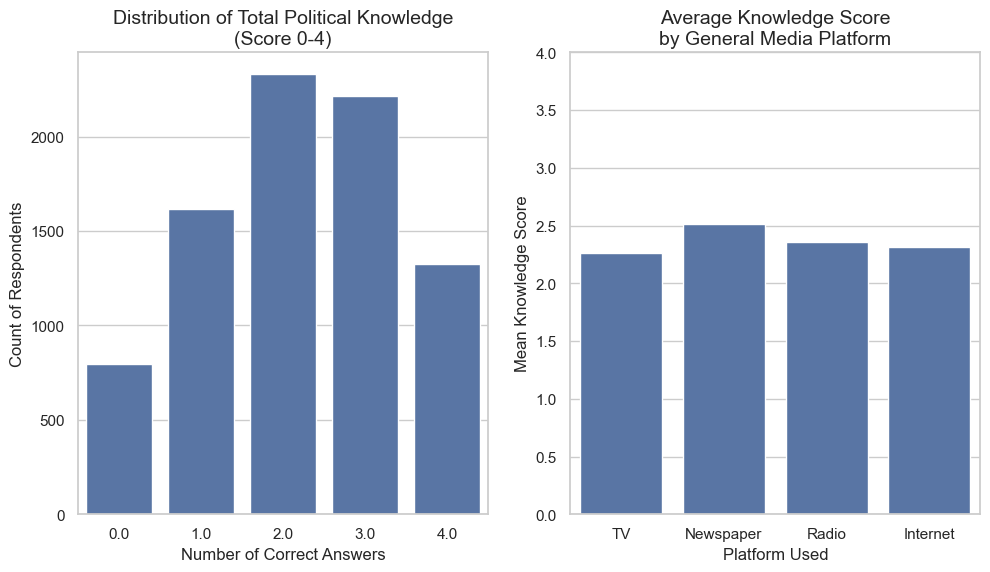

In [25]:
# 1. Create a "Total Knowledge Score" (Sum of the 4 recoded binary variables)
knowledge_vars = ["senator_term", "least_fed_spending", "house_majority", "senate_majority"]
model_df_recoded['total_knowledge'] = model_df_recoded[knowledge_vars].sum(axis=1)


# --- Generate 3 Visualizations ---

plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# Visualization 1: Distribution of Overall Political Knowledge
plt.subplot(1, 3, 1)
sns.countplot(data=model_df_recoded, x='total_knowledge')
plt.title('Distribution of Total Political Knowledge\n(Score 0-4)', fontsize=14)
plt.xlabel('Number of Correct Answers', fontsize=12)
plt.ylabel('Count of Respondents', fontsize=12)

# Visualization 2: Knowledge Score by General Media Type
# We compare the mean knowledge score for users of the 4 primary platforms
platforms = ['tv_used', 'newspaper_used', 'radio_used', 'internet_used']
platform_means = [model_df_recoded[model_df_recoded[p] == 1]['total_knowledge'].mean() for p in platforms]
platform_labels = ['TV', 'Newspaper', 'Radio', 'Internet']

plt.subplot(1, 3, 2)
sns.barplot(x=platform_labels, y=platform_means)
plt.title('Average Knowledge Score\nby General Media Platform', fontsize=14)
plt.xlabel('Platform Used', fontsize=12)
plt.ylabel('Mean Knowledge Score', fontsize=12)
plt.ylim(0, 4) # Scale 0 to 4

# Visualization 3: Knowledge Score by Partisan and Neutral Outlets
# Contrast Fox (Hannity), MSNBC (Maddow), and a Neutral/International source (BBC)
partisan_vars = ['sean_hannity_fox', 'rachel_maddow_msnbc', 'bbc_site']
partisan_means = [model_df_recoded[model_df_recoded[p] == 1]['total_knowledge'].mean() for p in partisan_vars]
partisan_labels = ['Hannity (Fox)', 'Maddow (MSNBC)', 'BBC (Neutral)']

plt.subplot(1, 3, 3)
sns.barplot(x=partisan_labels, y=partisan_means)
plt.title('Average Knowledge Score\nby Specific News Outlet', fontsize=14)
plt.xlabel('Outlet Used', fontsize=12)
plt.ylabel('Mean Knowledge Score', fontsize=12)
plt.ylim(0, 4)

plt.tight_layout()
plt.show()

interpretation of the graphs results here

---

## Discussion of Survey Design
- How might question wording affect your findings?
- What response biases might be present in this data?
- How do ANES sampling and weighting procedures affect interpretation?
- Compare self-report survey data to behavioral/observational data for your topic

All about ANES

if NOT using weighting... based on sampling strategy. compares to large census data / ACS to determine weights and applies. sampling strategy from ANES
ANES website